# The Meaning of the Exponential $e$

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on **Euler's number $e$**
(Week 1 — Derivatives and Optimization).

This notebook explains:

- Euler's number $e \approx 2.71828$ and its irrationality
- the definition $e = \lim_{n\to\infty}\left(1 + \tfrac1n\right)^n$
- the **compound-interest** story (banks paying more often → more money → $e$)
- continuous compounding as "bank infinity"
- the special property that $f(x) = e^x$ is **its own derivative**

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*The Inverse Function and Its Derivative*.

## 1. Euler's number

$e$ is one of the most important numbers in mathematics, appearing across calculus,
statistics, probability, and science. It is **irrational** (its decimals never terminate or
repeat):

$$
e = 2.718281828\ldots
$$

One way to define it is the limit

$$
e = \lim_{n\to\infty}\left(1 + \frac1n\right)^n .
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def approx_e(n):
    return (1 + 1/n)**n

print(f"{'n':>8} | {'(1+1/n)^n':>12}")
print("-" * 24)
for n in [1, 10, 100, 1000, 10000, 1_000_000]:
    print(f"{n:>8} | {approx_e(n):>12.6f}")
print(f"\ntrue e = {np.e:.6f}")

       n |    (1+1/n)^n
------------------------
       1 |     2.000000
      10 |     2.593742
     100 |     2.704814
    1000 |     2.716924
   10000 |     2.718146
 1000000 |     2.718280

true e = 2.718282


## 2. The special property: $e^x$ is its own derivative

$e$ is singled out because the function $f(x) = e^x$ **equals its own derivative**:

$$
\frac{d}{dx}e^x = e^x .
$$

This is why $e$ shows up everywhere growth or change is proportional to the current amount.
(The full derivation is the next lecture.)

In [2]:
x = sp.symbols('x')
print("d/dx e^x =", sp.diff(sp.exp(x), x), "  (its own derivative)")

d/dx e^x = exp(x)   (its own derivative)


## 3. The compound-interest story

A nice way to *discover* $e$: shopping for a bank.

- **Bank 1** pays **100%** interest once a year.
- **Bank 2** pays **50%** twice a year (every 6 months).
- **Bank 3** pays **33%** three times a year (every 4 months).

Which is best? Starting with \$1, each bank multiplies your money by $(1 + \tfrac1n)$ each
of its $n$ periods, so after a year you have $\left(1 + \tfrac1n\right)^n$.

In [3]:
def end_of_year(n, principal=1.0):
    return principal * (1 + 1/n)**n

for n, name in [(1, "Bank 1 (100% once)"),
                (2, "Bank 2 (50% twice)"),
                (3, "Bank 3 (33% thrice)")]:
    print(f"{name:>22}: $1 -> ${end_of_year(n):.4f}  =  (1 + 1/{n})^{n}")

    Bank 1 (100% once): $1 -> $2.0000  =  (1 + 1/1)^1
    Bank 2 (50% twice): $1 -> $2.2500  =  (1 + 1/2)^2
   Bank 3 (33% thrice): $1 -> $2.3704  =  (1 + 1/3)^3


### Accrued interest

Bank 3 beats Bank 2 beats Bank 1 because of **accrued (compound) interest**: interest
earns interest. With Bank 3, $\$1 \to 1+\tfrac13 \to (1+\tfrac13)^2 \to (1+\tfrac13)^3 =
2.37$. Compounding more often captures more of this effect.

Over **4 years** the gap widens (raise the yearly factor to the 4th power):

In [4]:
print("after 4 years (start $1):")
for n, name in [(1, "Bank 1"), (2, "Bank 2"), (3, "Bank 3")]:
    factor = (1 + 1/n)**n
    print(f"  {name}: ${factor**4:.2f}")

after 4 years (start $1):
  Bank 1: $16.00
  Bank 2: $25.63
  Bank 3: $31.57


## 4. More subdivisions → "bank infinity"

More compounding periods is always better:

- **Bank 12** (monthly): $(1+\tfrac1{12})^{12}$
- **Bank 365** (daily): $(1+\tfrac1{365})^{365}$
- **Bank $\infty$** (continuous): pays an infinitesimal of your money at every instant.

As $n \to \infty$, the year-end factor converges to **$e$**:

$$
\left(1 + \frac1n\right)^n \;\xrightarrow[n\to\infty]{}\; e = 2.71828\ldots
$$

So $e$ is exactly the money you'd have after one year of **continuous compounding** at 100%
on \$1.

In [5]:
for n, name in [(12, "Bank 12 (monthly)"),
                (365, "Bank 365 (daily)"),
                (8760, "Bank 8760 (hourly)"),
                (31_536_000, "Bank ~per-second")]:
    print(f"{name:>22}: ${end_of_year(n):.6f}")
print(f"{'Bank infinity (= e)':>22}: ${np.e:.6f}")

     Bank 12 (monthly): $2.613035
      Bank 365 (daily): $2.714567
    Bank 8760 (hourly): $2.718127
      Bank ~per-second: $2.718282
   Bank infinity (= e): $2.718282


### Visualizing the convergence to $e$

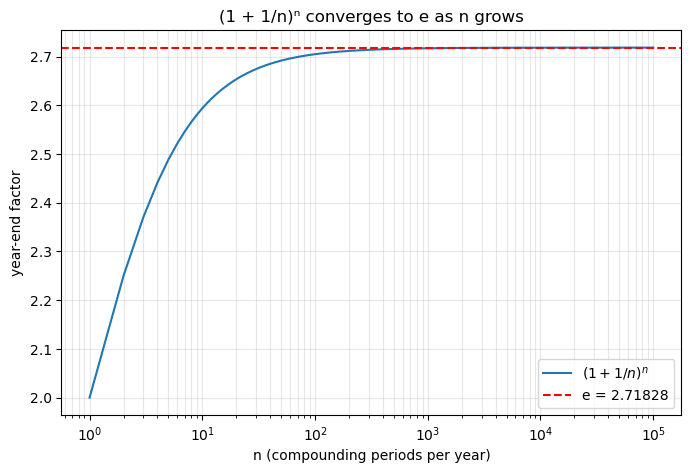

In [6]:
ns = np.unique(np.logspace(0, 5, 200).astype(int))
vals = (1 + 1/ns)**ns

plt.figure(figsize=(8, 5))
plt.semilogx(ns, vals, label=r"$(1+1/n)^n$")
plt.axhline(np.e, color="red", ls="--", label=f"e = {np.e:.5f}")
plt.title("(1 + 1/n)ⁿ converges to e as n grows")
plt.xlabel("n (compounding periods per year)"); plt.ylabel("year-end factor")
plt.grid(True, alpha=0.3, which="both"); plt.legend()
plt.show()

## 5. Exercises

### Basic
1. Write the limit definition of $e$.
2. What is special about the derivative of $f(x) = e^x$?

### Intermediate
3. Compute the year-end factor for Bank 2, Bank 3, and Bank 12, and order them.
4. Approximate $e$ with $(1+1/n)^n$ for $n = 50{,}000$. How close is it?

### Advanced
5. With continuous compounding, \$1 at 100% for one year becomes $e$. How much would \$1000
   become after 3 years of continuous compounding at 100%? (Use $1000\,e^{3}$.)
6. Explain why compounding more frequently yields more money (accrued interest).

## 6. Solutions / Checks

In [7]:
# 3.
for n in (2, 3, 12):
    print(f"3. Bank {n}: {(1+1/n)**n:.5f}")

# 4.
n = 50000
print(f"4. (1+1/{n})^{n} = {(1+1/n)**n:.6f}, |error| = {abs((1+1/n)**n - np.e):.2e}")

# 5.
print(f"5. $1000 * e^3 = ${1000*np.e**3:.2f}")

print("\n1. e = lim_{n->∞} (1 + 1/n)^n")
print("2. It is its own derivative: d/dx e^x = e^x.")
print("6. Interest paid earlier itself earns interest (compounding), so more frequent "
      "payouts accrue more.")

3. Bank 2: 2.25000
3. Bank 3: 2.37037
3. Bank 12: 2.61304
4. (1+1/50000)^50000 = 2.718255, |error| = 2.72e-05
5. $1000 * e^3 = $20085.54

1. e = lim_{n->∞} (1 + 1/n)^n
2. It is its own derivative: d/dx e^x = e^x.
6. Interest paid earlier itself earns interest (compounding), so more frequent payouts accrue more.


## 7. Conclusion

- **Euler's number** $e \approx 2.71828$ is irrational and defined by
  $e = \lim_{n\to\infty}\left(1 + \tfrac1n\right)^n$.
- The **compound-interest** story makes it concrete: paying $\tfrac1n$ of your money $n$
  times a year gives $(1+\tfrac1n)^n$, and "bank infinity" (continuous compounding) gives
  exactly $e$.
- Its defining calculus property is that $\dfrac{d}{dx}e^x = e^x$ — it is **its own
  derivative**.
- Next we'll see *why* $e^x$ is its own derivative, and the derivative of $\ln x$.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (13).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **the meaning of the exponential $e$**. Key spoken points, lightly
cleaned:

> Euler's number $e \approx 2.71828\ldots$ is irrational and appears across mathematics.
> One definition is $(1+1/n)^n$: for $n = 1$ it's $2$, for $10$ it's $2.594$, for $100$
> it's $2.705$, for $1000$ it's $2.717$ — converging to $e$. A key property: $f(x) = e^x$ is
> its own derivative. A nice way to see $e$ is interest rates. Bank 1 pays 100% once a year
> ($1 \to 2$); Bank 2 pays 50% twice ($1 \to 2.25 = (1+1/2)^2$); Bank 3 pays a third thrice
> ($1 \to 2.37 = (1+1/3)^3$) — Bank 3 is best because of accrued (compound) interest. Over 4
> years: \$16, \$25.63, \$31.57. More subdivisions are better: Bank 12 (monthly) gives
> $2.61$, Bank 365 (daily) gives $2.7145$, and "bank infinity" — continuous compounding,
> $1/\infty$ of your money infinitely often — gives the limit of $(1+1/n)^n$, which is $e$.